# Mapping von Institutionen

In [1]:
from google.cloud import bigquery
import pandas as pd
from typing import Union
import re
import json
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
sns.set_style('whitegrid')
plt.rc('font', family='Arial')
plt.rc('font', size=9) 
plt.rc('axes', titlesize=9) 
plt.rc('axes', labelsize=9) 
plt.rc('xtick', labelsize=9) 
plt.rc('ytick', labelsize=9) 
plt.rc('legend', fontsize=9)

In [3]:
client = bigquery.Client(project='subugoe-collaborative')

In [4]:
kb = client.query(f"""
                    SELECT 
                        CASE 
                            -- WHEN kb_inst.ror = 'https://ror.org/021ft0n22' THEN 'Universitätsmedizin Göttingen' # in der KB-Kodierung als GAU kodiert
                            WHEN kb_inst.ror = 'https://ror.org/02w2y2t16' THEN 'Leuphana Universität Lüneburg'
                            WHEN kb_inst.ror = 'https://ror.org/033n9gh91' THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN kb_inst.ror = 'https://ror.org/02vvvm705' THEN 'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth'
                            WHEN kb_inst.ror = 'https://ror.org/01bc76c69' THEN 'Hochschule Emden/Leer'
                            WHEN kb_inst.ror = 'https://ror.org/0304hq317' THEN 'Gottfried Wilhelm Leibniz Universität Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00x67m532' THEN 'Hochschule für Musik, Theater und Medien Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/03m2kj587' THEN 'Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/015qjqf64' THEN 'Stiftung Tierärztliche Hochschule Hannover'
                            WHEN kb_inst.ror = 'https://ror.org/00f2yqf98' THEN 'Medizinische Hochschule Hannover (MHH)'
                            WHEN kb_inst.ror = 'https://ror.org/00f5q5839' THEN 'HAWK Hochschule für angewandte Wissenschaft und Kunst'
                            WHEN kb_inst.ror = 'https://ror.org/02f9det96' THEN 'Stiftung Universität Hildesheim'
                            WHEN kb_inst.ror = 'https://ror.org/01y9bpm73' THEN 'Georg-August-Universität Göttingen'
                            WHEN kb_inst.ror = 'https://ror.org/010nsgg66' THEN 'Technische Universität Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/03aft2f80' THEN 'Hochschule für Bildende Künste Braunschweig'
                            WHEN kb_inst.ror = 'https://ror.org/01bk10867' THEN 'Ostfalia Hochschule für angewandte Wissenschaften'
                            WHEN kb_inst.ror = 'https://ror.org/04qb8nc58' THEN 'Technische Universität Clausthal'
                            WHEN kb_inst.ror = 'https://ror.org/04qmmjx98' THEN 'Universität Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/059vymd37' THEN 'Hochschule Osnabrück'
                            WHEN kb_inst.ror = 'https://ror.org/045y6d111' THEN 'Universität Vechta'
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 6612 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 316 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 315 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 5488 THEN 'Carl von Ossietzky Universität Oldenburg'
                            WHEN inst_id = 4564 THEN 'Carl von Ossietzky Universität Oldenburg'
                            ELSE ''
                        END AS parent_name,
                        CASE 
                            -- Ergänzung von Suborganisationen (Oldenburg)
                            WHEN inst_id = 445 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 6612 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 316 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 315 THEN 'Universitätsmedizin Oldenburg'
                            WHEN inst_id = 5488 THEN 'Helmholtz-Institut für Funktionelle Marine Biodiversität'
                            WHEN inst_id = 4564 THEN 'Institute for Science Networking Oldenburg GmbH'
                            ELSE 'not assigned'
                        END AS inst_name,
                        inst.address_full AS raw_affiliation_string,
                        doi
                    FROM `subugoe-collaborative.resources.kb_a_addr_inst_202601` AS inst
                    JOIN `subugoe-collaborative.resources.add_institution_lookup_kb_suppl_202601` AS kb_inst
                      ON inst.inst_id_top = kb_inst.inst_id
                    JOIN `subugoe-collaborative.openalex_walden.works` AS oal
                        ON CONCAT('https://openalex.org/', inst.item_id) = oal.id
                    WHERE oal.type IN ('article', 'review') 
                        AND is_paratext=FALSE 
                        AND is_retracted=FALSE 
                        AND is_xpac=FALSE
                        AND publication_year BETWEEN 2020 AND 2024
                        AND (kb_inst.ror IN (
                            'https://ror.org/021ft0n22', -- Universitätsmedizin Göttingen
                            'https://ror.org/02w2y2t16', -- Leuphana Universität Lüneburg
                            'https://ror.org/033n9gh91', -- Carl von Ossietzky Universität Oldenburg
                            'https://ror.org/02vvvm705', -- Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth
                            'https://ror.org/01bc76c69', -- Hochschule Emden/Leer
                            'https://ror.org/0304hq317', -- Gottfried Wilhelm Leibniz Universität Hannover
                            'https://ror.org/00x67m532', -- Hochschule für Musik, Theater und Medien Hannover
                            'https://ror.org/03m2kj587', -- Hochschule Hannover
                            'https://ror.org/015qjqf64', -- Stiftung Tierärztliche Hochschule Hannover
                            'https://ror.org/00f2yqf98', -- Medizinische Hochschule Hannover (MHH)
                            'https://ror.org/00f5q5839', -- HAWK Hochschule für angewandte Wissenschaft und Kunst
                            'https://ror.org/02f9det96', -- Stiftung Universität Hildesheim
                            'https://ror.org/01y9bpm73', -- Georg-August-Universität Göttingen
                            'https://ror.org/010nsgg66', -- Technische Universität Braunschweig
                            'https://ror.org/03aft2f80', -- Hochschule für Bildende Künste Braunschweig
                            'https://ror.org/01bk10867', -- Ostfalia Hochschule für angewandte Wissenschaften
                            'https://ror.org/04qb8nc58', -- Technische Universität Clausthal
                            'https://ror.org/04qmmjx98', -- Universität Osnabrück
                            'https://ror.org/059vymd37', -- Hochschule Osnabrück
                            'https://ror.org/045y6d111' -- Universität Vechta
                        ) OR kb_inst.inst_id IN (
                             -- Ergänzung von Suborganisationen (Oldenburg)
                             445, -- 'Evangelisches Krankenhaus Oldenburg'
                             6612, -- 'UMO - Universitätsmedizin Oldenburg'
                             316, -- 'Klinikum Oldenburg gGmbH'
                             315, -- 'Pius-Hospital Oldenburg'
                             5488, -- 'Helmholtz-Institut für Funktionelle Marine Biodiversität an der Universität Oldenburg (HIFMB)'
                             4564 -- Institute for Science Networking Oldenburg GmbH
                            )
                        )
                    ORDER BY inst_name
                    """).to_dataframe()

In [5]:
kb.replace({'Universitätsmedizin Oldenburg': 'Fakultät VI - Medizin und Gesundheitswissenschaften'}, inplace=True)

In [6]:
kb.head()

,parent_name,inst_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1073/pnas.2118156119
1,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,"Alfred Wegener Institute, Helmholtz Center for...",10.1073/pnas.2118156119
2,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1111/1755-0998.13779
3,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.3389/fmicb.2021.694508
4,Carl von Ossietzky Universität Oldenburg,Helmholtz-Institut für Funktionelle Marine Bio...,Helmholtz Institute for Functional Marine Biod...,10.1016/j.gecco.2022.e02238


In [10]:
with open('institution_mapping/mapping_tables_fak/clausthal.json', 'r') as file:
    CLAUSTHAL_MAPPING = json.load(file)

In [13]:
with open('institution_mapping/mapping_tables_fak/emden.json', 'r') as file:
    EMDEN_MAPPING = json.load(file)

In [14]:
with open('institution_mapping/mapping_tables_fak/gau.json', 'r') as file:
    GAU_MAPPING = json.load(file)

In [15]:
with open('institution_mapping/mapping_tables_fak/hawk.json', 'r') as file:
    HAWK_MAPPING = json.load(file)

In [16]:
with open('institution_mapping/mapping_tables_fak/hbk.json', 'r') as file:
    HBK_MAPPING = json.load(file)

In [17]:
with open('institution_mapping/mapping_tables_fak/hildesheim.json', 'r') as file:
    HILDESHEIM_MAPPING = json.load(file)

In [18]:
with open('institution_mapping/mapping_tables_fak/hmtmh.json', 'r') as file:
    HMTMH_MAPPING = json.load(file)

In [19]:
with open('institution_mapping/mapping_tables_fak/hsh.json', 'r') as file:
    HSH_MAPPING = json.load(file)

In [20]:
with open('institution_mapping/mapping_tables_fak/hsosnabrueck.json', 'r') as file:
    HSOSNABRÜCK_MAPPING = json.load(file)

In [21]:
with open('institution_mapping/mapping_tables_fak/jade.json', 'r') as file:
    JADE_MAPPING = json.load(file)

In [22]:
with open('institution_mapping/mapping_tables_fak/leibniz.json', 'r') as file:
    LEIBNIZ_MAPPING = json.load(file)

In [23]:
with open('institution_mapping/mapping_tables_fak/leuphana.json', 'r') as file:
    LEUPHANA_MAPPING = json.load(file)

In [24]:
with open('institution_mapping/mapping_tables_fak/mhh.json', 'r') as file:
    MHH_MAPPING = json.load(file)

In [25]:
with open('institution_mapping/mapping_tables_fak/oldenburg.json', 'r') as file:
    OLDENBURG_MAPPING = json.load(file)

In [26]:
with open('institution_mapping/mapping_tables_fak/ostfalia.json', 'r') as file:
    OSTFALIA_MAPPING = json.load(file)

In [27]:
with open('institution_mapping/mapping_tables_fak/tiho.json', 'r') as file:
    TIHO_MAPPING = json.load(file)

In [28]:
with open('institution_mapping/mapping_tables_fak/tubraunschweig.json', 'r') as file:
    TUBRAUNSCHWEIG_MAPPING = json.load(file)

In [29]:
with open('institution_mapping/mapping_tables_fak/uosnabrueck.json', 'r') as file:
    UOSNABRÜCK_MAPPING = json.load(file)

In [30]:
with open('institution_mapping/mapping_tables_fak/vechta.json', 'r') as file:
    VECHTA_MAPPING = json.load(file)

In [31]:
MAPPING_MASTER_TABLE = {
    'Technische Universität Clausthal': CLAUSTHAL_MAPPING,
    'Hochschule Emden/Leer': EMDEN_MAPPING,
    'Georg-August-Universität Göttingen': GAU_MAPPING,
    'HAWK Hochschule für angewandte Wissenschaft und Kunst': HAWK_MAPPING,
    'Hochschule für Bildende Künste Braunschweig': HBK_MAPPING,
    'Stiftung Universität Hildesheim': HILDESHEIM_MAPPING,
    'Hochschule für Musik, Theater und Medien Hannover': HMTMH_MAPPING,
    'Hochschule Hannover': HSH_MAPPING,
    'Hochschule Osnabrück': HSOSNABRÜCK_MAPPING,
    'Jade Hochschule Wilhelmshaven/Oldenburg/Elsfleth': JADE_MAPPING,
    'Gottfried Wilhelm Leibniz Universität Hannover': LEIBNIZ_MAPPING,
    'Leuphana Universität Lüneburg': LEUPHANA_MAPPING,
    'Medizinische Hochschule Hannover (MHH)': MHH_MAPPING,
    'Carl von Ossietzky Universität Oldenburg': OLDENBURG_MAPPING,
    'Ostfalia Hochschule für angewandte Wissenschaften': OSTFALIA_MAPPING,
    'Stiftung Tierärztliche Hochschule Hannover': TIHO_MAPPING,
    'Technische Universität Braunschweig': TUBRAUNSCHWEIG_MAPPING,
    'Universität Osnabrück': UOSNABRÜCK_MAPPING,
    'Universität Vechta': VECHTA_MAPPING
}

In [32]:
map_df = kb.copy()

In [33]:
def map_address(address: str, mapping_dict: dict) -> Union[str, None]:
    for k, v in mapping_dict.items():
        pattern = re.compile(r'|'.join(v), re.IGNORECASE)
        res = bool(pattern.search(address))
        if res:
            return k
    return None

In [34]:
for k, v in MAPPING_MASTER_TABLE.items():
    map_df.loc[map_df['parent_name'] == k, 'inst_name'] = \
           map_df.loc[map_df['parent_name'] == k]['raw_affiliation_string'].apply(map_address, mapping_dict=v)

In [35]:
map_df.loc[map_df.inst_name == 'Universitätsmedizin Göttingen (UMG)', 'parent_name'] = 'Universitätsmedizin Göttingen'

In [36]:
map_df.head()

,parent_name,inst_name,raw_affiliation_string,doi
0,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1073/pnas.2118156119
1,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,"Alfred Wegener Institute, Helmholtz Center for...",10.1073/pnas.2118156119
2,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1111/1755-0998.13779
3,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.3389/fmicb.2021.694508
4,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1016/j.gecco.2022.e02238


In [37]:
liste_aller_hochschulen = list(map_df.parent_name.unique())

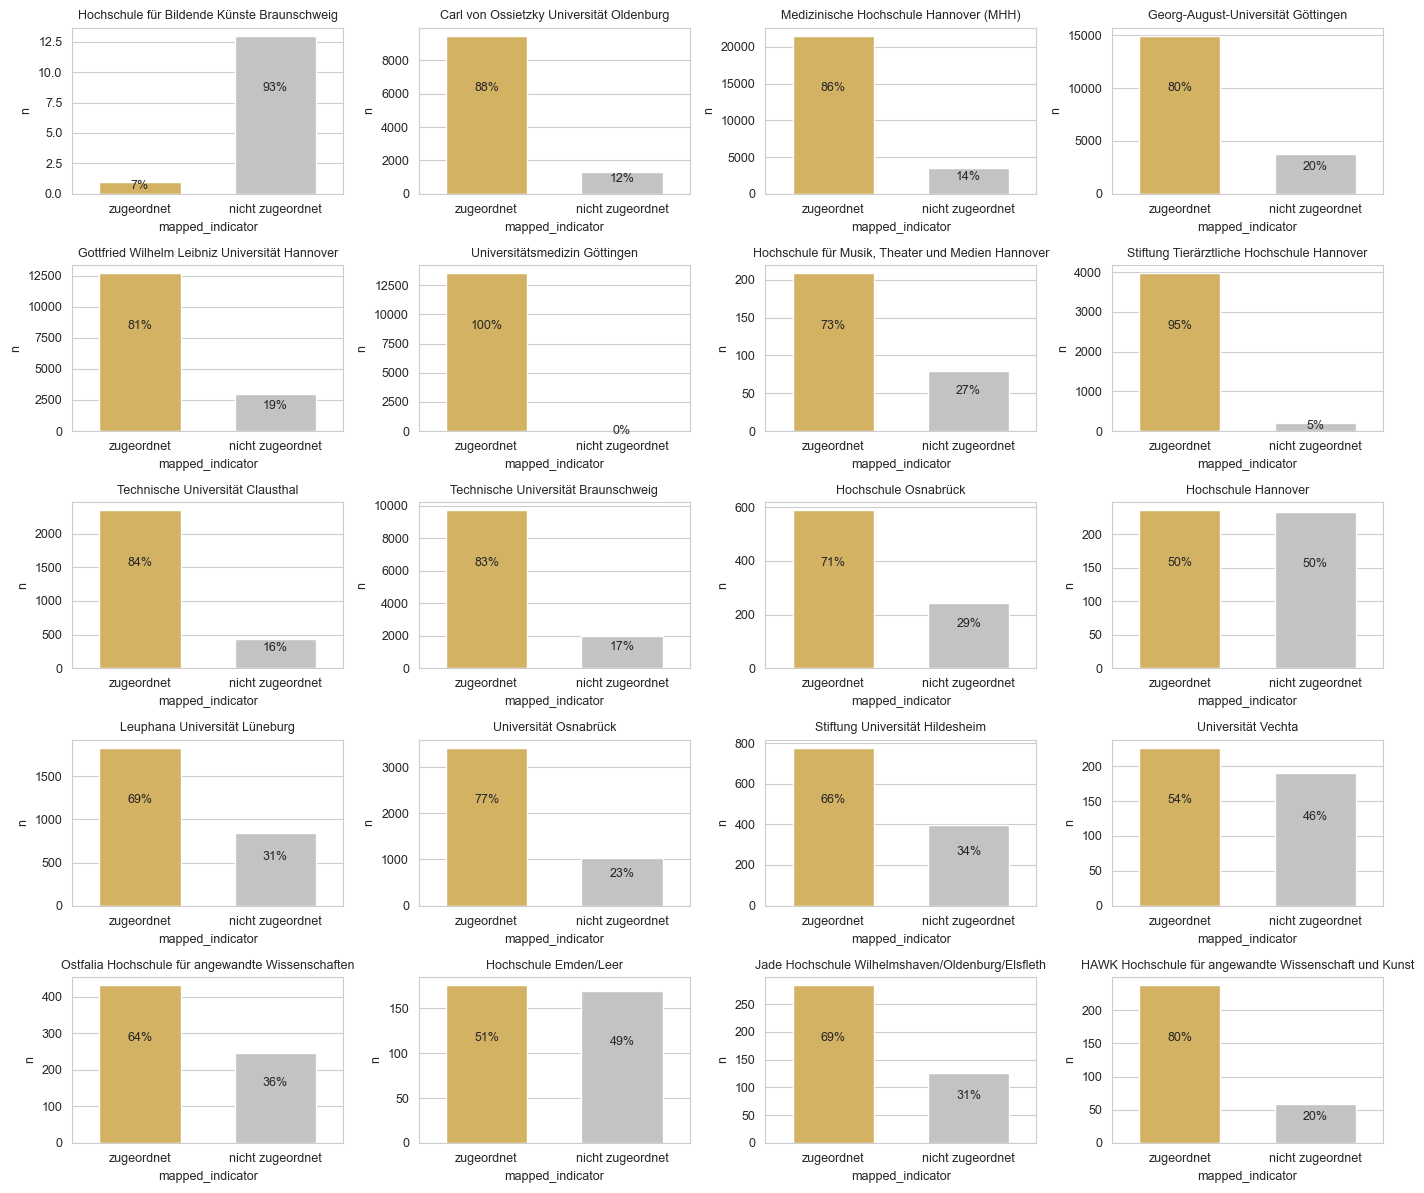

In [38]:
fig, axes = plt.subplots(nrows=5, 
                         ncols=4, 
                         sharex=False, 
                         sharey=False, 
                         figsize=(14,12))

axes = axes.reshape(-1)

for i, ax in enumerate(axes, 0):

    parent_name = liste_aller_hochschulen[i-1]

    df_temp = map_df[map_df.parent_name == parent_name].copy()
    df_temp.fillna('Nicht zugeordnet', inplace=True)

    number_of_items_mapped = df_temp[df_temp.inst_name != 'Nicht zugeordnet'].doi.count()
    number_of_items_not_mapped = df_temp[df_temp.inst_name == 'Nicht zugeordnet'].doi.count()

    prop = df_temp[df_temp.inst_name != 'Nicht zugeordnet'].doi.count() / df_temp.doi.count()

    data = {
        'mapped_indicator': ['zugeordnet', 'nicht zugeordnet'],
        'n': [number_of_items_mapped, number_of_items_not_mapped],
        'prop': [format(prop, '.0%'), format(1-prop, '.0%')]
    }
    
    df = pd.DataFrame(data)
    
    sns.barplot(data=df, 
                x='mapped_indicator', 
                y='n', 
                width=0.6,
                hue='mapped_indicator',
                palette=['#E5BA52', '#c3c3c3'],
                ax=ax).set_title(parent_name, fontdict=dict(fontsize=9, fontweight=500))

    for idx, row in df.iterrows():
        ax.text(row['mapped_indicator'], 
                row['n'] / 1.5, 
                row['prop'], 
                verticalalignment='center', 
                horizontalalignment='center', 
                fontdict=dict(fontsize=9, fontweight=500))

plt.tight_layout()

plt.show()

In [44]:
map_df.sample(10)

,parent_name,inst_name,raw_affiliation_string,doi
71721,Universitätsmedizin Göttingen,Universitätsmedizin Göttingen (UMG),"Department of Anesthesiology, Emergency and In...",10.1016/j.isci.2024.111168
103489,Medizinische Hochschule Hannover (MHH),Zentrum für Radiologie,Institute of Diagnostic and Interventional Neu...,10.1038/s41467-024-45933-5
41818,Ostfalia Hochschule für angewandte Wissenschaften,Fakultät Versorgungstechnik,Institute for Biotechnology and Environmental ...,10.1504/ijpec.2023.135479
100514,Gottfried Wilhelm Leibniz Universität Hannover,None,"Leibniz Universität Hannover, Hannover, Germany",10.14778/3529337.3529353
19267,Georg-August-Universität Göttingen,Fakultät für Biologie und Psychologie,"Biology Education, University of Göttingen, 37...",10.3390/educsci13020212
81035,Technische Universität Braunschweig,Fakultät für Lebenswissenschaften,"Institute of Organic Chemistry, Department of ...",10.1371/journal.pbio.3001022
95483,Gottfried Wilhelm Leibniz Universität Hannover,Fakultät für Mathematik und Physik,"Institute for Quantum Optics, Leibniz Universi...",10.1364/ao.478263
77340,Carl von Ossietzky Universität Oldenburg,Fakultät V - Mathematik und Naturwissenschaften,Helmholtz Institute for Functional Marine Biod...,10.1029/2023gb007740
10702,Stiftung Tierärztliche Hochschule Hannover,Klinik für Rinder,"Clinic for Cattle, University of Veterinary Me...",10.1371/journal.pone.0263294
38339,Universitätsmedizin Göttingen,Universitätsmedizin Göttingen (UMG),Institute of Pathology University Medical Cent...,10.1002/cam4.2994
